# Person-only YOLO26-m v0 — Colab L4 demo train
Fetches the published Kaggle dataset, trains YOLO26-m @ 640, runs inference on a few val images.
Run cells top to bottom. Cells 1–3 require user action (Drive mount, Kaggle creds upload); do them before launching the train in Cell 7.

### Cell 1 — verify GPU

In [1]:
# Confirm an L4 is attached before doing anything else.
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
import torch
assert torch.cuda.is_available(), "No GPU — set Runtime > Change runtime type > L4 GPU."
print("CUDA device:", torch.cuda.get_device_name(0))

NVIDIA L4, 23034 MiB
CUDA device: NVIDIA L4


### Cell 2 — mount Drive (user action: authorize popup)
Trained weights and run artifacts are saved here so they survive a session disconnect.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Destination for weights + results that must persist beyond this session.
DRIVE_OUT = '/content/drive/MyDrive/smart_spotter/person_v0'
os.makedirs(DRIVE_OUT, exist_ok=True)
print("Drive output dir:", DRIVE_OUT)

Mounted at /content/drive
Drive output dir: /content/drive/MyDrive/smart_spotter/person_v0


### Cell 3 — Kaggle credentials (user action: upload kaggle.json)
Get the token from Kaggle > Settings > Account > Create New API Token. Upload the downloaded `kaggle.json` when prompted.

In [3]:
import os, json

# Prefer kaggle.json already on Drive; otherwise prompt for upload.
drive_token = '/content/drive/MyDrive/smart_spotter/kaggle.json'
os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists(drive_token):
    import shutil
    shutil.copy(drive_token, '/root/.kaggle/kaggle.json')
    print("Using kaggle.json from Drive.")
else:
    from google.colab import files
    print("Upload your kaggle.json:")
    up = files.upload()
    assert 'kaggle.json' in up, "kaggle.json not uploaded."
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(up['kaggle.json'])
    # Stash a copy on Drive so future sessions skip the upload step.
    import shutil
    shutil.copy('/root/.kaggle/kaggle.json', drive_token)
    print("Saved a copy to Drive for next time.")

os.chmod('/root/.kaggle/kaggle.json', 0o600)
with open('/root/.kaggle/kaggle.json') as f:
    creds = json.load(f)
print("Authenticated as:", creds['username'])

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Saved a copy to Drive for next time.
Authenticated as: giladfaibish


### Cell 4 — install dependencies

In [4]:
# Ultralytics pulls a compatible torch; kaggle CLI for the dataset fetch.
!pip -q install --upgrade ultralytics kaggle
import ultralytics
ultralytics.checks()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 47.1/235.7 GB disk)


### Cell 5 — download + unzip the dataset
The published dataset is the single archive `person_bulk_yolo.zip`. The Kaggle download itself is wrapped in an outer zip, so we unwrap twice. Retries while the dataset finishes server-side processing.

In [5]:
import os, glob, time, subprocess, zipfile

SLUG = 'giladfaibish/smart-spotter-person-yolo-v0'
DL_DIR = '/content/dl'
DATA_ROOT = '/content/data'  # final extracted tree lives here
os.makedirs(DL_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

# Retry the download — a freshly-published dataset can 404 for a few minutes.
for attempt in range(1, 11):
    r = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', SLUG, '-p', DL_DIR, '--force'],
        capture_output=True, text=True
    )
    if r.returncode == 0 and glob.glob(os.path.join(DL_DIR, '*.zip')):
        print(f"Download OK on attempt {attempt}.")
        break
    print(f"Attempt {attempt} not ready yet; waiting 60s...")
    print((r.stderr or r.stdout)[:300])
    time.sleep(60)
else:
    raise RuntimeError("Dataset never became downloadable — check the Kaggle dataset page.")

# Outer unwrap: Kaggle's transfer container.
outer = sorted(glob.glob(os.path.join(DL_DIR, '*.zip')), key=os.path.getsize)[-1]
print("Outer archive:", outer, f"({os.path.getsize(outer)/(1024**3):.2f} GB)")
with zipfile.ZipFile(outer) as zf:
    zf.extractall(DL_DIR)

# Inner unwrap: the real dataset archive person_bulk_yolo.zip.
inner = glob.glob(os.path.join(DL_DIR, '**', 'person_bulk_yolo.zip'), recursive=True)
if inner:
    print("Inner archive:", inner[0])
    with zipfile.ZipFile(inner[0]) as zf:
        zf.extractall(DATA_ROOT)
else:
    # If --dir-mode zip was omitted at publish time, the single file is the dataset.
    print("No inner archive; treating outer extraction as the dataset root.")
    # person_bulk_yolo.zip may have extracted directly into DL_DIR contents
    direct = glob.glob(os.path.join(DL_DIR, '**', 'person_bulk_yolo'), recursive=True)
    if not direct:
        # Fall back: maybe the outer zip WAS person_bulk_yolo.zip
        with zipfile.ZipFile(outer) as zf:
            zf.extractall(DATA_ROOT)

print("Extraction done.")

Download OK on attempt 1.
Outer archive: /content/dl/smart-spotter-person-yolo-v0.zip (10.45 GB)
No inner archive; treating outer extraction as the dataset root.
Extraction done.


### Cell 6 — locate the dataset root + write a demo data.yaml
Overrides the bundled `nc: 2` yaml with a clean person-only `nc: 1` for an unambiguous demo. Uses absolute Colab paths.

In [8]:
import os, glob

# Search both the download dir and the data dir for images/train.
hits = (glob.glob('/content/dl/**/images/train', recursive=True)
        + glob.glob('/content/data/**/images/train', recursive=True))
assert hits, "Could not find images/train under /content/dl or /content/data"
DATASET_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("Dataset root:", DATASET_DIR)

# Sanity counts.
for split in ('train', 'val'):
    n_img = len(glob.glob(os.path.join(DATASET_DIR, 'images', split, '*')))
    n_lbl = len(glob.glob(os.path.join(DATASET_DIR, 'labels', split, '*')))
    print(f"{split}: {n_img} images / {n_lbl} labels")

# Demo-only person-only yaml. Final unified train will use nc:2 {person,drone}.
YAML_PATH = '/content/person_v0.yaml'
with open(YAML_PATH, 'w') as f:
    f.write(f"path: {DATASET_DIR}\n")
    f.write("train: images/train\n")
    f.write("val: images/val\n")
    f.write("nc: 1\n")
    f.write("names:\n  0: person\n")
print("Wrote", YAML_PATH)
print(open(YAML_PATH).read())

Dataset root: /content/dl/person_bulk_yolo
train: 65717 images / 65717 labels
val: 7301 images / 7301 labels
Wrote /content/person_v0.yaml
path: /content/dl/person_bulk_yolo
train: images/train
val: images/val
nc: 1
names:
  0: person



### Cell 7 — train YOLO26-m @ 640 on the L4
640 / 40 epochs / batch 32, early stopping at patience 15. No `cache=ram` (decoded-image RAM far exceeds the limit). Project dir is on Drive so checkpoints survive a disconnect.

In [9]:
from ultralytics import YOLO

# Pretrained YOLO26-m backbone. Falls back to yolo11m if the 26 weight name
# is unavailable in the installed Ultralytics build.
try:
    model = YOLO('yolo26m.pt')
    print("Using yolo26m.pt")
except Exception as e:
    print("yolo26m.pt unavailable, falling back to yolo11m.pt:", e)
    model = YOLO('yolo11m.pt')

# Optional: concise one-line summary printed after each epoch's validation.
# Fires between epochs only, so it adds no per-step training overhead.
def _epoch_summary(trainer):
    e = trainer.epoch + 1
    m = trainer.metrics or {}
    p = m.get('metrics/precision(B)', float('nan'))
    r = m.get('metrics/recall(B)', float('nan'))
    map50 = m.get('metrics/mAP50(B)', float('nan'))
    map5095 = m.get('metrics/mAP50-95(B)', float('nan'))
    print(f">> epoch {e:>3}/{trainer.epochs} | P={p:.3f} R={r:.3f} "
          f"mAP50={map50:.3f} mAP50-95={map5095:.3f}")

model.add_callback('on_fit_epoch_end', _epoch_summary)

results = model.train(
    data=YAML_PATH,
    epochs=40,
    imgsz=640,
    batch=32,
    patience=15,          # stop if val mAP plateaus — demo will converge early
    cache=False,          # never cache=ram at this scale
    workers=8,
    device=0,
    project=DRIVE_OUT,    # checkpoints written straight to Drive
    name='train',
    exist_ok=True,
    plots=True,
    verbose=True,         # per-batch progress bar + per-class val table
)
print("Best weights:", os.path.join(DRIVE_OUT, 'train', 'weights', 'best.pt'))

Using yolo26m.pt
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/person_v0.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

### Cell 8 — run inference on a few val images for the demo
Saves annotated detection images to Drive and displays them inline.

In [ ]:
import glob, os, random
from ultralytics import YOLO
from IPython.display import Image, display

best = os.path.join(DRIVE_OUT, 'train', 'weights', 'best.pt')
det = YOLO(best)

# Sample a handful of val images.
val_imgs = glob.glob(os.path.join(DATASET_DIR, 'images', 'val', '*'))
random.seed(0)
sample = random.sample(val_imgs, min(8, len(val_imgs)))

pred = det.predict(
    source=sample,
    imgsz=640,
    conf=0.25,
    save=True,
    project=DRIVE_OUT,
    name='demo_preds',
    exist_ok=True,
)

pred_dir = os.path.join(DRIVE_OUT, 'demo_preds')
for p in sorted(glob.glob(os.path.join(pred_dir, '*')))[:8]:
    display(Image(filename=p, width=640))
print("Annotated demo images saved to:", pred_dir)

### Cell 9 - Export trained YOLO model

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.1 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading: /content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.pt
Local val images gone; re-downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/giladfaibish/smart-spotter-person-yolo-v0
License(s): CC0-1.0
100% 10.5G/10.5G [10:13<00:00, 18.3MB/s]


0: 640x640 2 persons, 18.0ms
1: 640x640 1 person, 18.0ms
2: 640x640 8 persons, 18.0ms
3: 640x640 2 persons, 18.0ms
4: 640x640 3 persons, 18.0ms
5: 640x640 34 persons, 18.0ms
6: 640x640 1 person, 18.0ms
7: 640x640 12 persons, 18.0

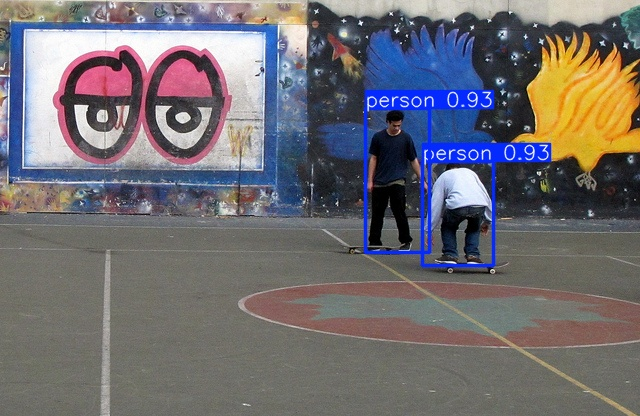

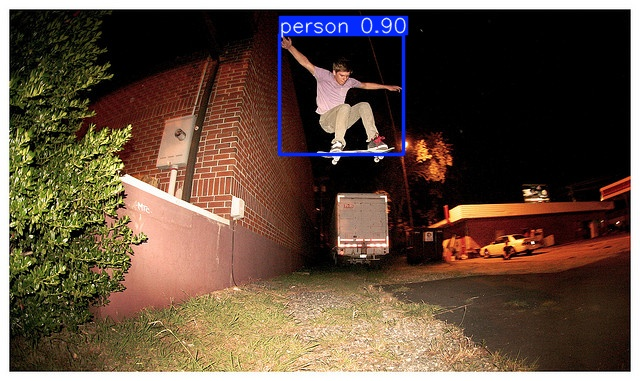

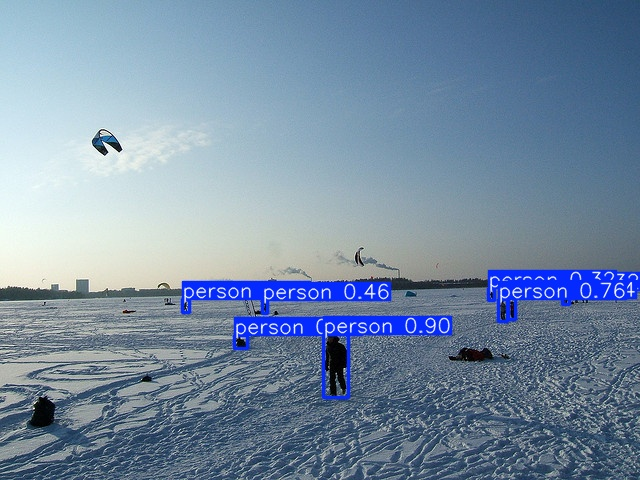

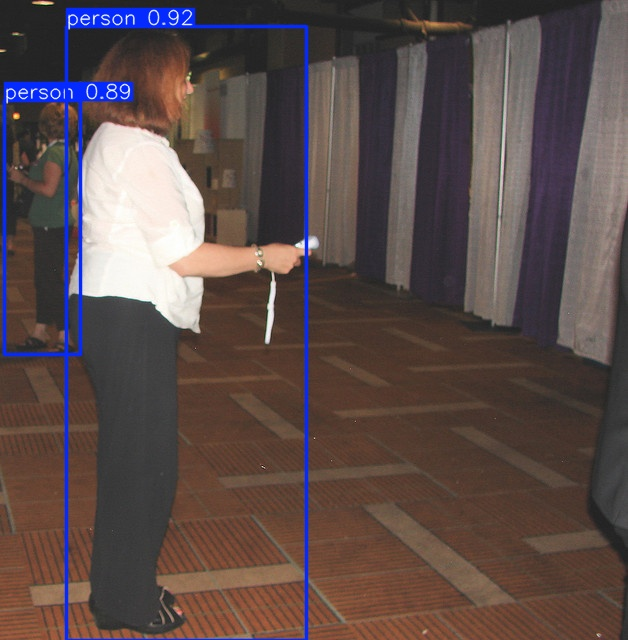

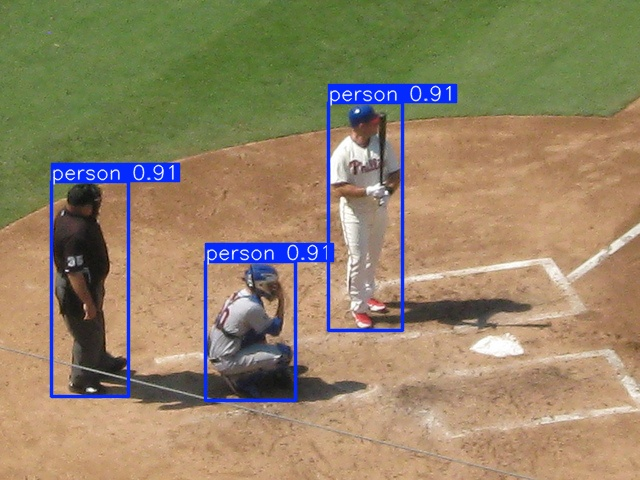

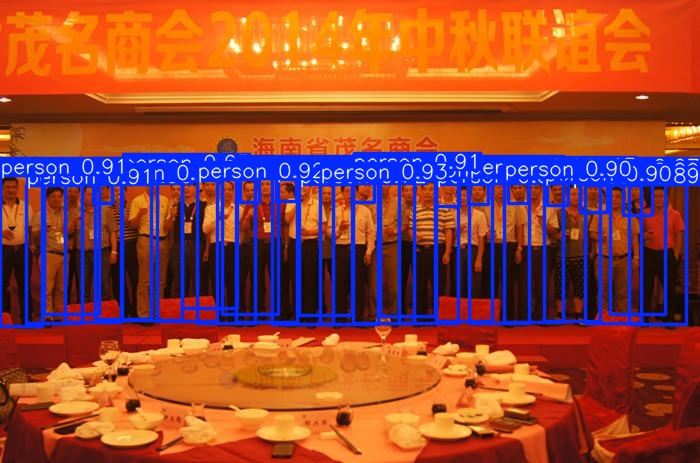

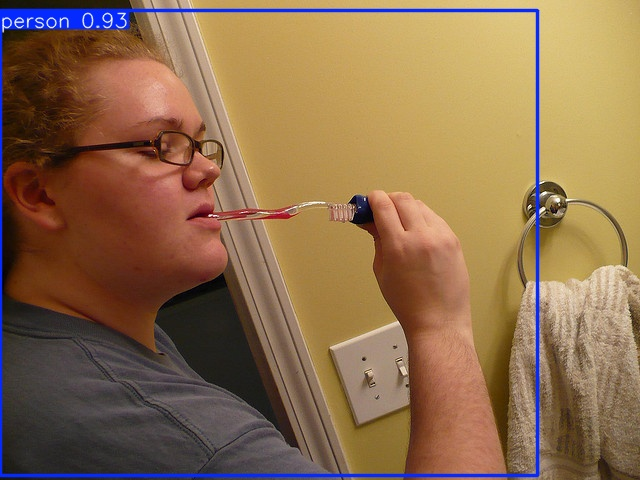

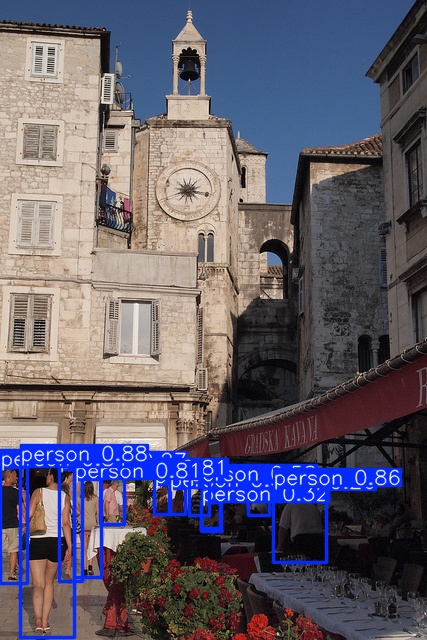

Annotated demo images saved to: /content/drive/MyDrive/smart_spotter/person_v0/demo_preds


In [1]:
# Standalone re-run after runtime disconnect. Weights already on Drive.
!pip -q install --upgrade ultralytics

from google.colab import drive
drive.mount('/content/drive')

import glob, os, random
from ultralytics import YOLO
from IPython.display import Image, display

DRIVE_OUT = '/content/drive/MyDrive/smart_spotter/person_v0'
best = os.path.join(DRIVE_OUT, 'train', 'weights', 'best.pt')
assert os.path.exists(best), f"best.pt not found at {best}"
print("Loading:", best)
det = YOLO(best)

# Val images were extracted to /content/dl by the original run. If the runtime
# was recycled, that local dir is gone — re-fetch only if missing.
val_dir = '/content/dl/person_bulk_yolo/images/val'
if not glob.glob(os.path.join(val_dir, '*')):
    print("Local val images gone; re-downloading dataset...")
    os.makedirs('/root/.kaggle', exist_ok=True)
    import shutil
    shutil.copy('/content/drive/MyDrive/smart_spotter/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !pip -q install kaggle
    !kaggle datasets download -d giladfaibish/smart-spotter-person-yolo-v0 -p /content/dl --force
    import zipfile
    outer = sorted(glob.glob('/content/dl/*.zip'), key=os.path.getsize)[-1]
    with zipfile.ZipFile(outer) as zf:
        zf.extractall('/content/dl')

val_imgs = glob.glob(os.path.join(val_dir, '*'))
random.seed(0)
sample = random.sample(val_imgs, min(8, len(val_imgs)))

det.predict(
    source=sample, imgsz=640, conf=0.25, save=True,
    project=DRIVE_OUT, name='demo_preds', exist_ok=True,
)

pred_dir = os.path.join(DRIVE_OUT, 'demo_preds')
for p in sorted(glob.glob(os.path.join(pred_dir, '*')))[:8]:
    display(Image(filename=p, width=640))
print("Annotated demo images saved to:", pred_dir)

In [2]:
# ---- Export trained YOLO -> FP32 static-shape ONNX for downstream trtexec ----
# The ONNX is consumed by trtexec on the Orin to build an FP16 engine.
# Precision is chosen at engine-build time (trtexec --fp16), NOT baked here.
import os, glob
import numpy as np
from ultralytics import YOLO

DRIVE_OUT = '/content/drive/MyDrive/smart_spotter/person_v0'
best = os.path.join(DRIVE_OUT, 'train', 'weights', 'best.pt')
assert os.path.exists(best), f"best.pt not found at {best}"

IMGSZ = 640  # MUST match training input size (640 for this person-only v0)

model = YOLO(best)
class_names = model.names  # index -> name mapping baked into the weights
print("Class index -> name mapping:", class_names)

# TRT-friendly export: FP32, static shape, simplified graph, no embedded NMS.
onnx_path = model.export(
    format="onnx",
    imgsz=IMGSZ,
    opset=17,         # safe for TRT 10.x
    dynamic=False,    # fixed input shape -> simpler/faster static engine downstream
    simplify=True,    # onnx-simplifier: clean graph for TRT
    half=False,       # keep ONNX FP32; FP16 selected at engine build via --fp16
    nms=False,        # raw head output; NMS handled in device inference code
)
print("\nExported ONNX:", onnx_path)

# Copy the ONNX to Drive so it survives a runtime disconnect.
import shutil
drive_onnx = os.path.join(DRIVE_OUT, 'train', 'weights', os.path.basename(onnx_path))
if os.path.abspath(onnx_path) != os.path.abspath(drive_onnx):
    shutil.copy(onnx_path, drive_onnx)
    print("Copied ONNX to Drive:", drive_onnx)

# ---- Verify the ONNX: structure + load-back + dummy inference ----
import onnx
import onnxruntime as ort

m = onnx.load(onnx_path)
onnx.checker.check_model(m)
print("\nonnx.checker: OK")

# Input tensor name + shape.
inp = m.graph.input[0]
in_name = inp.name
in_shape = [d.dim_value if d.dim_value > 0 else d.dim_param
            for d in inp.type.tensor_type.shape.dim]
print(f"Input : name={in_name!r} shape={in_shape}")

# Output tensor name(s) + shape(s).
for out in m.graph.output:
    out_shape = [d.dim_value if d.dim_value > 0 else d.dim_param
                 for d in out.type.tensor_type.shape.dim]
    print(f"Output: name={out.name!r} shape={out_shape}")

# Load back with onnxruntime and run one dummy inference.
sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
ort_in = sess.get_inputs()[0]
dummy = np.random.rand(1, 3, IMGSZ, IMGSZ).astype(np.float32)
outputs = sess.run(None, {ort_in.name: dummy})

print("\n--- onnxruntime dummy inference ---")
for o_meta, o_val in zip(sess.get_outputs(), outputs):
    print(f"Output {o_meta.name!r}: runtime shape={o_val.shape}")

# Interpret the raw head output: channels = 4 (box) + nc (class scores).
main = outputs[0]
assert main.ndim == 3, f"Unexpected output rank {main.ndim}; expected 3 (batch, channels, anchors)"
channels = main.shape[1]
nc_from_onnx = channels - 4
print(f"\nChannels (4 box + nc): {channels}  ->  nc = {nc_from_onnx}")
print(f"Class count from weights: {len(class_names)}")
assert nc_from_onnx == len(class_names), \
    f"ONNX nc ({nc_from_onnx}) != weights nc ({len(class_names)})"
print("Class-count check: OK")

print("\nDeploy notes for the Orin:")
print(f"  - ONNX is FP32, static input {in_shape}, no embedded NMS.")
print(f"  - Build engine: trtexec --onnx={os.path.basename(onnx_path)} --fp16 --saveEngine=model.engine")
print(f"  - Device-side: apply confidence threshold + NMS on the raw [1,{channels},N] output.")
print(f"  - Class mapping: {class_names}")

Class index -> name mapping: {0: 'person'}
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 202ms
Prepared 4 packages in 1.58s
Installed 4 packages in 248ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success 

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 8.6s, saved as '/content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.onnx' (77.9 MB)

Export complete (9.6s)
Results saved to /content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.onnx imgsz=640 data=/content/person_v0.yaml  
Visualize:       https://netron.app

Exported ONNX: /content/drive/MyDrive/smart_spotter/person_v0/train/weights/best.onnx

onnx.checker: OK
Input : name='images' shape=[1, 3, 640, 640]
Output: name='output0' shape=[1, 300, 6]

--- onnxruntime dummy inference ---
Output 'output0': runtime shape=(1, 300, 6)

Channels (4 box + nc): 300  ->  nc = 296
Class count from weights: 1


AssertionError: ONNX nc (296) != weights nc (1)

In [3]:
# ---- Verify the ONNX: structure + load-back + dummy inference ----
import onnx
import onnxruntime as ort

m = onnx.load(onnx_path)
onnx.checker.check_model(m)
print("\nonnx.checker: OK")

inp = m.graph.input[0]
in_name = inp.name
in_shape = [d.dim_value if d.dim_value > 0 else d.dim_param
            for d in inp.type.tensor_type.shape.dim]
print(f"Input : name={in_name!r} shape={in_shape}")

for out in m.graph.output:
    out_shape = [d.dim_value if d.dim_value > 0 else d.dim_param
                 for d in out.type.tensor_type.shape.dim]
    print(f"Output: name={out.name!r} shape={out_shape}")

sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
ort_in = sess.get_inputs()[0]
dummy = np.random.rand(1, 3, IMGSZ, IMGSZ).astype(np.float32)
outputs = sess.run(None, {ort_in.name: dummy})

print("\n--- onnxruntime dummy inference ---")
for o_meta, o_val in zip(sess.get_outputs(), outputs):
    print(f"Output {o_meta.name!r}: runtime shape={o_val.shape}")

# YOLO26 exports END-TO-END: output is [batch, max_det, 6] = [x1,y1,x2,y2,conf,cls].
# Decoding + NMS are baked into the graph (NMS-free one-to-one head).
main = outputs[0]
assert main.ndim == 3, f"Unexpected output rank {main.ndim}; expected 3"
batch, max_det, cols = main.shape
print(f"\nOutput layout: [batch={batch}, max_det={max_det}, cols={cols}]")
assert cols == 6, f"Expected 6 cols [x1,y1,x2,y2,conf,cls], got {cols}"

# Class ids appear in the last column; validate they fall within the trained range.
cls_col = main[0, :, 5]
max_cls_id = int(cls_col.max()) if main[0].size else 0
print(f"Max class id seen in dummy output: {max_cls_id}")
print(f"Class count from weights: {len(class_names)}")
assert max_cls_id < len(class_names) or main[0].size == 0, \
    f"Class id {max_cls_id} out of range for nc={len(class_names)}"
print("Class-range check: OK")

print("\nDeploy notes for the Orin:")
print(f"  - ONNX is FP32, static input {in_shape}, END-TO-END (NMS baked in).")
print(f"  - Output {out_shape}: rows are [x1, y1, x2, y2, conf, class_id].")
print(f"  - Build engine: trtexec --onnx=best.onnx --fp16 --saveEngine=model.engine")
print(f"  - Device-side: filter rows by conf column; boxes are xyxy in {IMGSZ}px input space. No manual NMS needed.")
print(f"  - Class mapping: {class_names}")


onnx.checker: OK
Input : name='images' shape=[1, 3, 640, 640]
Output: name='output0' shape=[1, 300, 6]

--- onnxruntime dummy inference ---
Output 'output0': runtime shape=(1, 300, 6)

Output layout: [batch=1, max_det=300, cols=6]
Max class id seen in dummy output: 0
Class count from weights: 1
Class-range check: OK

Deploy notes for the Orin:
  - ONNX is FP32, static input [1, 3, 640, 640], END-TO-END (NMS baked in).
  - Output [1, 300, 6]: rows are [x1, y1, x2, y2, conf, class_id].
  - Build engine: trtexec --onnx=best.onnx --fp16 --saveEngine=model.engine
  - Device-side: filter rows by conf column; boxes are xyxy in 640px input space. No manual NMS needed.
  - Class mapping: {0: 'person'}
